Rama 1: min(1 + r*omega'(r)) = 0.784194
Rama 2: min(1 + r*omega'(r)) = 0.776932
Rama 3: min(1 + r*omega'(r)) = 0.769382
Rama 4: min(1 + r*omega'(r)) = 0.761565
Rama 5: min(1 + r*omega'(r)) = 0.753511
Rama 6: min(1 + r*omega'(r)) = 0.745259
Rama 7: min(1 + r*omega'(r)) = 0.736862
Rama 8: min(1 + r*omega'(r)) = 0.728382
Rama 9: min(1 + r*omega'(r)) = 0.719890
Rama 10: min(1 + r*omega'(r)) = 0.711467
Rama 11: min(1 + r*omega'(r)) = 0.703197
Rama 12: min(1 + r*omega'(r)) = 0.695169
Rama 13: min(1 + r*omega'(r)) = 0.687467
Rama 14: min(1 + r*omega'(r)) = 0.680175
Rama 15: min(1 + r*omega'(r)) = 0.673366
Rama 16: min(1 + r*omega'(r)) = 0.667101
Rama 17: min(1 + r*omega'(r)) = 0.661434
Rama 18: min(1 + r*omega'(r)) = 0.656402
Rama 19: min(1 + r*omega'(r)) = 0.652031
Rama 20: min(1 + r*omega'(r)) = 0.648336
Rama 21: min(1 + r*omega'(r)) = 0.645321
Rama 22: min(1 + r*omega'(r)) = 0.642986
Rama 23: min(1 + r*omega'(r)) = 0.641325
Rama 24: min(1 + r*omega'(r)) = 0.640331


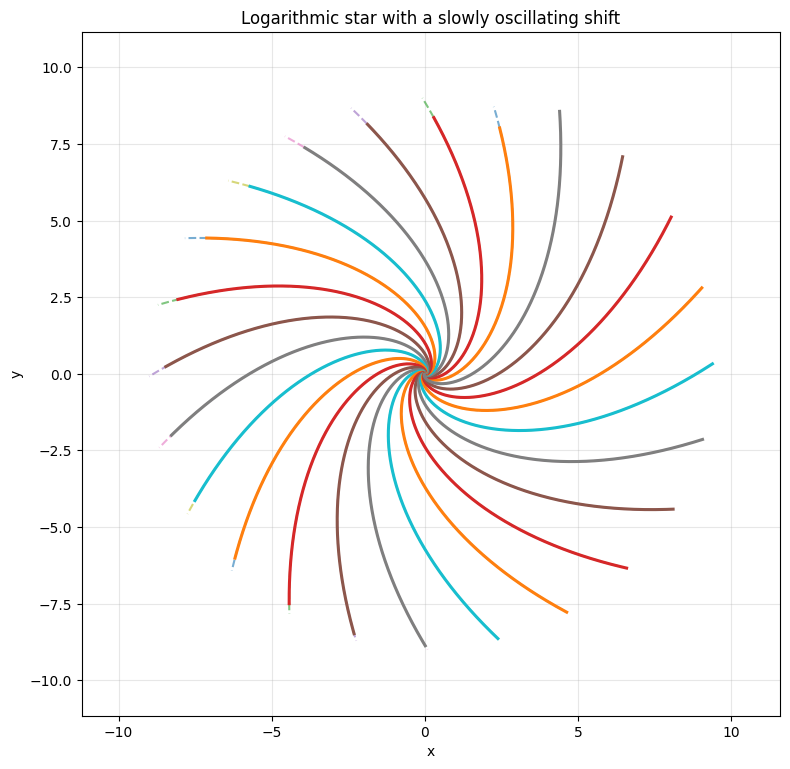

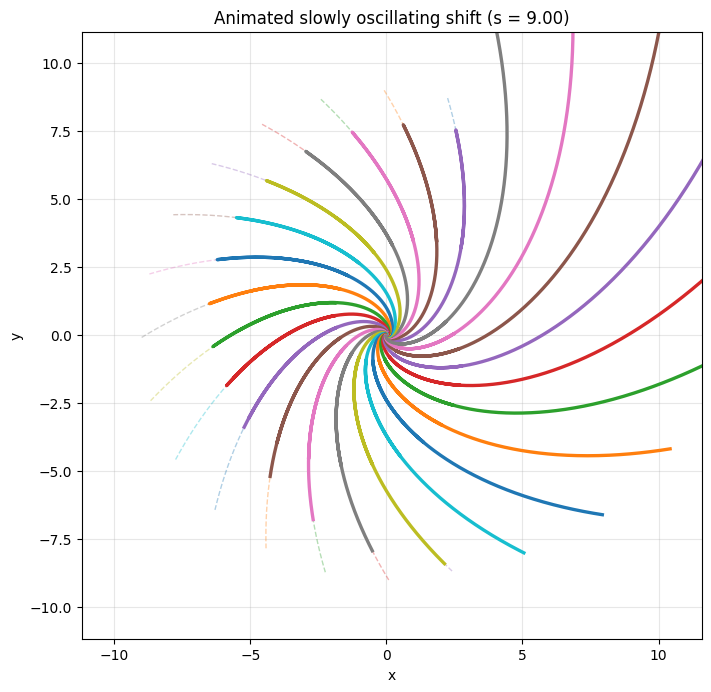

Se guardaron los archivos:
 - slowly_oscillating_shift.png
 - slowly_oscillating_shift.gif


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ============================================================
# Parámetros de la logarithmic star
# ============================================================
delta = 1.2          # si delta = 0, son rayos; si delta != 0, espirales logarítmicas
N = 24                # número de ramas
r_min = 0.01
r_max = 9.0
num_points = 2800

# Ángulos beta_k
betas = np.linspace(0, 2*np.pi, N, endpoint=False)

# Parámetro radial en escala logarítmica
r = np.geomspace(r_min, r_max, num_points)

# ============================================================
# Parámetros del slowly oscillating shift
# ============================================================
a = 0.40             # amplitud pequeña para asegurar difeomorfismo radial
nu = 2.3             # frecuencia en variable log(r)
phases = np.linspace(0, np.pi, N, endpoint=False)  # una fase por rama

# ============================================================
# Rama original de la logarithmic star
# z_k(r) = e^{i beta_k} r^{1+i delta}
#        = r * exp(i(beta_k + delta log r))
# ============================================================
def logarithmic_star_branch(r, beta, delta):
    theta = beta + delta * np.log(r)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

# ============================================================
# Función omega_k(r): slowly oscillating
# omega_k(r) = a sin(nu log r + phase_k) / sqrt(1 + (log r)^2)
# ============================================================
def omega(r, a=0.18, nu=2.0, phase=0.0):
    t = np.log(r)
    return a * np.sin(nu * t + phase) / np.sqrt(1.0 + t**2)

# ============================================================
# Derivada omega'(r), útil para verificar que el cambio radial
# rho(r) = r exp(omega(r)) sea estrictamente creciente
# ============================================================
def omega_prime(r, a=0.18, nu=2.0, phase=0.0):
    t = np.log(r)
    g = np.sqrt(1.0 + t**2)
    d_omega_dt = a * (
        nu * np.cos(nu * t + phase) / g
        - t * np.sin(nu * t + phase) / (g**3)
    )
    return d_omega_dt / r

# ============================================================
# Rama desplazada por slowly oscillating shift
#
# alpha(e^{i beta} r^{1+i delta})
#   = e^{i beta} (r e^{s omega(r)})^{1+i delta}
#
# donde s in [0,1] permite animar la deformación
# ============================================================
def shifted_branch(r, beta, delta, a=0.18, nu=2.0, phase=0.0, s=9.0):
    w = omega(r, a=a, nu=nu, phase=phase)
    rho = r * np.exp(s * w)
    theta = beta + delta * np.log(rho)
    x = rho * np.cos(theta)
    y = rho * np.sin(theta)
    return x, y

# ============================================================
# Verificación numérica de orientación preservada:
# rho'(r) = exp(omega(r)) * (1 + r omega'(r))
# Queremos 1 + r omega'(r) > 0
# ============================================================
for j, phase in enumerate(phases):
    test = 1.0 + r * omega_prime(r, a=a, nu=nu, phase=phase)
    min_val = np.min(test)
    print(f"Rama {j+1}: min(1 + r*omega'(r)) = {min_val:.6f}")
    if min_val <= 0:
        raise ValueError(
            "La amplitud/frecuencia elegida no preserva orientación. "
            "Reduce 'a' o 'nu'."
        )

# ============================================================
# Cálculo de límites del gráfico
# ============================================================
all_x = []
all_y = []

for j, beta in enumerate(betas):
    x0, y0 = logarithmic_star_branch(r, beta, delta)
    x1, y1 = shifted_branch(r, beta, delta, a=a, nu=nu, phase=phases[j], s=1.0)

    all_x.extend(x0)
    all_y.extend(y0)
    all_x.extend(x1)
    all_y.extend(y1)

xmin, xmax = min(all_x), max(all_x)
ymin, ymax = min(all_y), max(all_y)

dx = xmax - xmin
dy = ymax - ymin
margin = 0.12

xlim = (xmin - margin * dx, xmax + margin * dx)
ylim = (ymin - margin * dy, ymax + margin * dy)

# ============================================================
# FIGURA ESTÁTICA: estrella original + shift final
# ============================================================
fig, ax = plt.subplots(figsize=(8, 8))

for j, beta in enumerate(betas):
    # original
    x0, y0 = logarithmic_star_branch(r, beta, delta)
    ax.plot(x0, y0, linestyle="--", linewidth=1.5, alpha=0.6)

    # desplazada
    x1, y1 = shifted_branch(r, beta, delta, a=a, nu=nu, phase=phases[j], s=1.0)
    ax.plot(x1, y1, linewidth=2.2)

ax.set_aspect('equal')
ax.set_title('Logarithmic star with a slowly oscillating shift')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

plt.tight_layout()
plt.savefig("slowly_oscillating_shift.png", dpi=220)
plt.show()

# ============================================================
# GIF: deformación continua desde la identidad (s=0)
# hasta el shift completo (s=1)
# ============================================================
fig2, ax2 = plt.subplots(figsize=(8, 8))
ax2.set_aspect('equal')
ax2.set_title('Animated slowly oscillating shift on a logarithmic star')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)

# Fondo: estrella original fija
for beta in betas:
    x0, y0 = logarithmic_star_branch(r, beta, delta)
    ax2.plot(x0, y0, linestyle="--", linewidth=1.0, alpha=0.35)

# Líneas animadas: imagen por alpha_s
lines = [ax2.plot([], [], linewidth=2.4)[0] for _ in betas]

def init():
    for line in lines:
        line.set_data([], [])
    return lines

def update(frame):
    s = frame  # frame ya vendrá en [0,1]
    for j, beta in enumerate(betas):
        x, y = shifted_branch(
            r, beta, delta,
            a=a, nu=nu, phase=phases[j],
            s=s
        )
        lines[j].set_data(x, y)
    ax2.set_title(f'Animated slowly oscillating shift (s = {s:.2f})')
    return lines

frames = np.linspace(0.0, 5.0, 100)

anim = FuncAnimation(
    fig2,
    update,
    frames=frames,
    init_func=init,
    blit=True,
    interval=45
)

anim.save("slowly_oscillating_shift.gif", writer=PillowWriter(fps=22))
plt.show()

print("Se guardaron los archivos:")
print(" - slowly_oscillating_shift.png")
print(" - slowly_oscillating_shift.gif")

Verificación de orientación preservada:
  Rama 1: min(1 + r*omega'(r)) = 0.406610
  Rama 2: min(1 + r*omega'(r)) = 0.406610
  Rama 3: min(1 + r*omega'(r)) = 0.406610
  Rama 4: min(1 + r*omega'(r)) = 0.406610
  Rama 5: min(1 + r*omega'(r)) = 0.406610
  Rama 6: min(1 + r*omega'(r)) = 0.406610
  Rama 7: min(1 + r*omega'(r)) = 0.406610
  Rama 8: min(1 + r*omega'(r)) = 0.406610
  Rama 9: min(1 + r*omega'(r)) = 0.406610
  Rama 10: min(1 + r*omega'(r)) = 0.406610
  Rama 11: min(1 + r*omega'(r)) = 0.406610
  Rama 12: min(1 + r*omega'(r)) = 0.406610
  Rama 13: min(1 + r*omega'(r)) = 0.406610
  Rama 14: min(1 + r*omega'(r)) = 0.406610
  Rama 15: min(1 + r*omega'(r)) = 0.406610
  Rama 16: min(1 + r*omega'(r)) = 0.406610
  Rama 17: min(1 + r*omega'(r)) = 0.406610
  Rama 18: min(1 + r*omega'(r)) = 0.406610
  Rama 19: min(1 + r*omega'(r)) = 0.406610
  Rama 20: min(1 + r*omega'(r)) = 0.406610
  Rama 21: min(1 + r*omega'(r)) = 0.406610
  Rama 22: min(1 + r*omega'(r)) = 0.406610
  Rama 23: min(1 + r*om

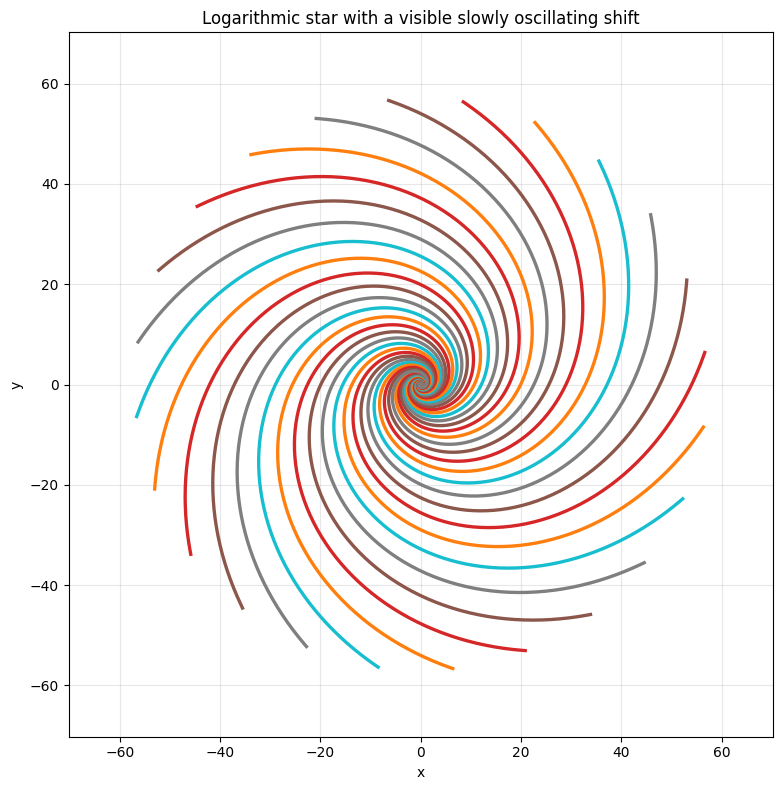

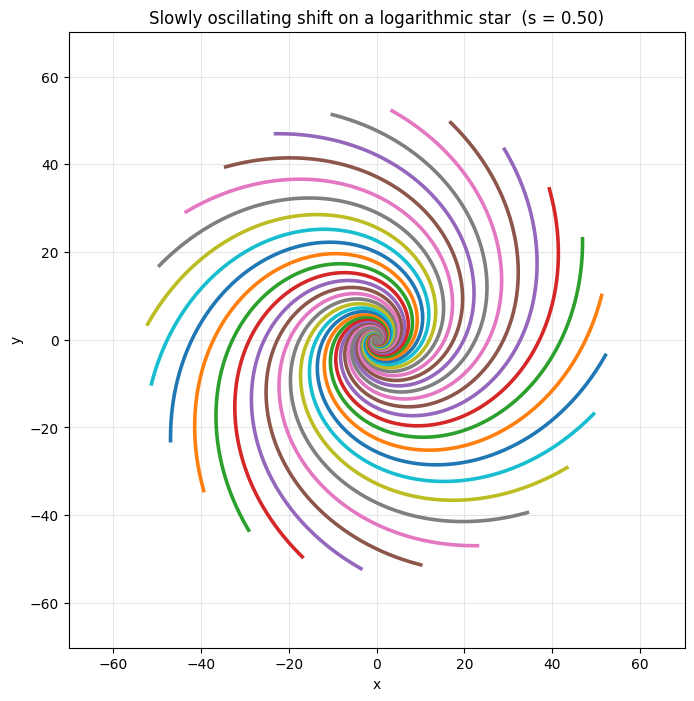


Se guardaron los archivos:
 - slowly_oscillating_shift_visible.png
 - slowly_oscillating_shift_visible.gif


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ============================================================
# PARÁMETROS GENERALES
# ============================================================
delta = 2.1          # más grande => el cambio radial produce también cambio angular visible
N = 24                # número de ramas
r_min = 0.01
r_max = 48.0
num_points = 1600

# Ángulos beta_k
betas = np.linspace(0, 2*np.pi, N, endpoint=False)

# Radio en escala logarítmica
r = np.geomspace(r_min, r_max, num_points)

# ============================================================
# PARÁMETROS DEL SLOWLY OSCILLATING SHIFT
# ============================================================
a = 0.42             # amplitud del shift (más grande => más visible)
nu = 2.1             # frecuencia en log(r)
phases = np.zeros(N) # todas las ramas en fase para que el movimiento global se note más

# ============================================================
# RAMA ORIGINAL DE LA LOGARITHMIC STAR
# z_k(r) = e^{i beta_k} r^{1+i delta}
#        = r * exp(i(beta_k + delta log r))
# ============================================================
def logarithmic_star_branch(r, beta, delta):
    theta = beta + delta * np.log(r)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

# ============================================================
# FUNCIÓN OMEGA(r): SLOWLY OSCILLATING
# Decae lentamente cuando r -> 0 y r -> infinito
# ============================================================
def omega(r, a=0.42, nu=2.1, phase=0.0):
    t = np.log(r)
    return a * np.sin(nu * t + phase) / (1.0 + 0.35 * np.abs(t))

# ============================================================
# DERIVADA DE OMEGA(r)
# Se usa para verificar orientación:
# rho(r) = r exp(omega(r))
# rho'(r) = exp(omega(r)) * (1 + r omega'(r))
# ============================================================
def omega_prime(r, a=0.42, nu=2.1, phase=0.0):
    t = np.log(r)
    denom = 1.0 + 0.35 * np.abs(t)
    sign_t = np.sign(t)

    d_omega_dt = a * (
        nu * np.cos(nu * t + phase) / denom
        - 0.35 * sign_t * np.sin(nu * t + phase) / (denom**2)
    )
    return d_omega_dt / r

# ============================================================
# RAMA DEFORMADA POR EL SHIFT
#
# alpha_s(e^{i beta} r^{1+i delta})
#   = e^{i beta} (r e^{s omega(r)})^{1+i delta}
#
# s in [0,1] controla cuánta deformación se aplica
# ============================================================
def shifted_branch(r, beta, delta, a=0.42, nu=2.1, phase=0.0, s=1.0):
    w = omega(r, a=a, nu=nu, phase=phase)
    rho = r * np.exp(s * w)
    theta = beta + delta * np.log(rho)
    x = rho * np.cos(theta)
    y = rho * np.sin(theta)
    return x, y

# ============================================================
# VERIFICACIÓN NUMÉRICA DE ORIENTACIÓN PRESERVADA
# Queremos 1 + r*omega'(r) > 0
# ============================================================
print("Verificación de orientación preservada:")
for j, phase in enumerate(phases):
    test = 1.0 + r * omega_prime(r, a=a, nu=nu, phase=phase)
    min_val = np.min(test)
    print(f"  Rama {j+1}: min(1 + r*omega'(r)) = {min_val:.6f}")
    if min_val <= 0:
        raise ValueError(
            "La elección de parámetros no preserva orientación. "
            "Reduce 'a' o 'nu'."
        )

# ============================================================
# LÍMITES DEL GRÁFICO
# Incluimos estrella original y shift máximo
# ============================================================
all_x = []
all_y = []

for j, beta in enumerate(betas):
    x0, y0 = logarithmic_star_branch(r, beta, delta)
    x1, y1 = shifted_branch(r, beta, delta, a=a, nu=nu, phase=phases[j], s=1.0)

    all_x.extend(x0)
    all_y.extend(y0)
    all_x.extend(x1)
    all_y.extend(y1)

xmin, xmax = min(all_x), max(all_x)
ymin, ymax = min(all_y), max(all_y)

dx = xmax - xmin
dy = ymax - ymin
margin = 0.12

xlim = (xmin - margin * dx, xmax + margin * dx)
ylim = (ymin - margin * dy, ymax + margin * dy)

# ============================================================
# FIGURA ESTÁTICA
# Original (línea punteada) + shift final (línea continua)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 8))

for j, beta in enumerate(betas):
    x0, y0 = logarithmic_star_branch(r, beta, delta)
    x1, y1 = shifted_branch(r, beta, delta, a=a, nu=nu, phase=phases[j], s=1.0)

    ax.plot(x0, y0, linestyle="--", linewidth=1.2, alpha=0.45, label=None)
    ax.plot(x1, y1, linewidth=2.4, label=None)

ax.set_aspect('equal')
ax.set_title('Logarithmic star with a visible slowly oscillating shift')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

plt.tight_layout()
plt.savefig("slowly_oscillating_shift_visible.png", dpi=220)
plt.show()

# ============================================================
# GIF ANIMADO
# La deformación va y viene:
# s = 0.5 + 0.5*sin(frame)
# Así el movimiento se percibe mucho mejor
# ============================================================
fig2, ax2 = plt.subplots(figsize=(8, 8))
ax2.set_aspect('equal')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)

# Estrella original fija al fondo
for beta in betas:
    x0, y0 = logarithmic_star_branch(r, beta, delta)
    ax2.plot(x0, y0, linestyle="--", linewidth=1.0, alpha=0.25)

# Líneas animadas
lines = [ax2.plot([], [], linewidth=2.6)[0] for _ in betas]

def init():
    for line in lines:
        line.set_data([], [])
    return lines

def update(frame):
    # s oscila entre 0 y 1
    s = 0.5 + 0.5 * np.sin(frame)

    for j, beta in enumerate(betas):
        x, y = shifted_branch(
            r,
            beta,
            delta,
            a=a,
            nu=nu,
            phase=phases[j],
            s=s
        )
        lines[j].set_data(x, y)

    ax2.set_title(f'Slowly oscillating shift on a logarithmic star  (s = {s:.2f})')
    return lines

frames = np.linspace(0, 2*np.pi, 180)

anim = FuncAnimation(
    fig2,
    update,
    frames=frames,
    init_func=init,
    blit=True,
    interval=40
)

anim.save("slowly_oscillating_shift_visible.gif", writer=PillowWriter(fps=24))
plt.show()

print("\nSe guardaron los archivos:")
print(" - slowly_oscillating_shift_visible.png")
print(" - slowly_oscillating_shift_visible.gif")